# 🎲 Probability & Statistics for AI

Machine Learning models operate under uncertainty. Understanding statistics allows us to:
- **Summarize and clean datasets** using descriptive metrics.
- **Update belief probabilities** using Bayes' Theorem.
- **Detect anomalies and outliers** using Gaussian distributions and Z-scores.
- **Rely on the Central Limit Theorem (CLT)** for sampling stability.

Let's explore these concepts interactively with visuals!


---
## 1. Descriptive Statistics: Outlier Sensitivity

The **Mean** is sensitive to extreme values, whereas the **Median** and **IQR** are robust.


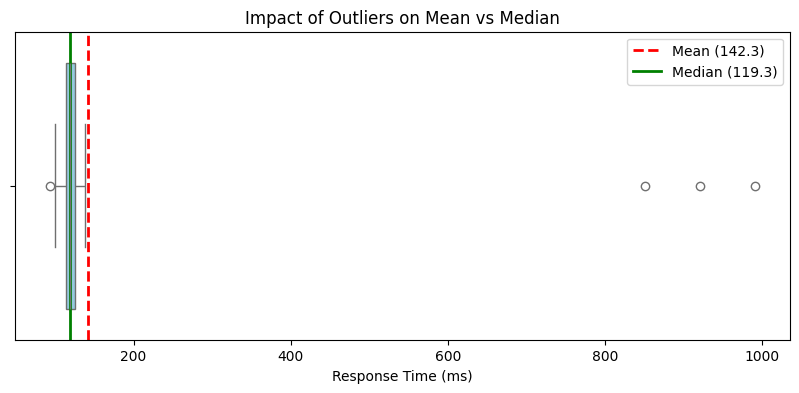

Mean: 142.29 ms | Median: 119.28 ms


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate normal data with heavy outliers
np.random.seed(42)
data = np.random.normal(loc=120, scale=10, size=100)
outliers = np.array([850, 920, 990])
full_data = np.concatenate([data, outliers])

mean_val = np.mean(full_data)
median_val = np.median(full_data)

plt.figure(figsize=(10, 4))
sns.boxplot(x=full_data, color='skyblue')
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_val:.1f})')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median ({median_val:.1f})')
plt.title('Impact of Outliers on Mean vs Median')
plt.xlabel('Response Time (ms)')
plt.legend()
plt.show()

print(f'Mean: {mean_val:.2f} ms | Median: {median_val:.2f} ms')


---
## 2. Bayes' Theorem in Action

Bayes' Theorem updates the prior probability $P(A)$ given new evidence $B$:
$$P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}$$


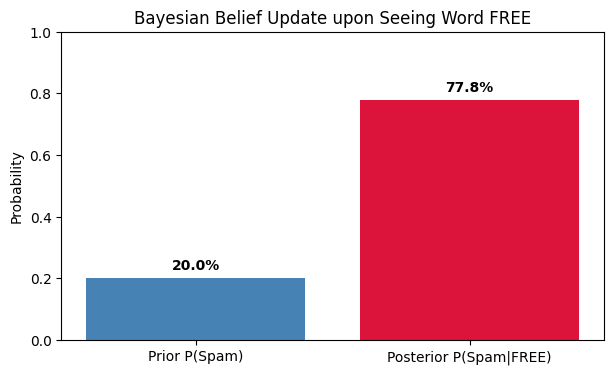

In [2]:
# Prior P(Spam)
p_spam = 0.20
p_ham = 0.80

# Likelihood P('FREE' | Spam) vs P('FREE' | Ham)
p_free_given_spam = 0.70
p_free_given_ham = 0.05

# Evidence P('FREE')
p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)

# Posterior P(Spam | 'FREE')
p_spam_given_free = (p_free_given_spam * p_spam) / p_free

plt.figure(figsize=(7, 4))
bars = plt.bar(['Prior P(Spam)', 'Posterior P(Spam|FREE)'], [p_spam, p_spam_given_free], color=['steelblue', 'crimson'])
plt.ylabel('Probability')
plt.ylim(0, 1.0)
plt.title('Bayesian Belief Update upon Seeing Word FREE')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval*100:.1f}%', ha='center', va='bottom', fontweight='bold')
plt.show()


---
## 3. Gaussian Normal Distribution & Z-Score Anomaly Detection

A Gaussian distribution is defined by mean $\mu$ and standard deviation $\sigma$:
$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$
A **Z-score** measures standard deviations from the mean: $Z = \frac{x - \mu}{\sigma}$. Data points with $|Z| \ge 3$ are severe anomalies.


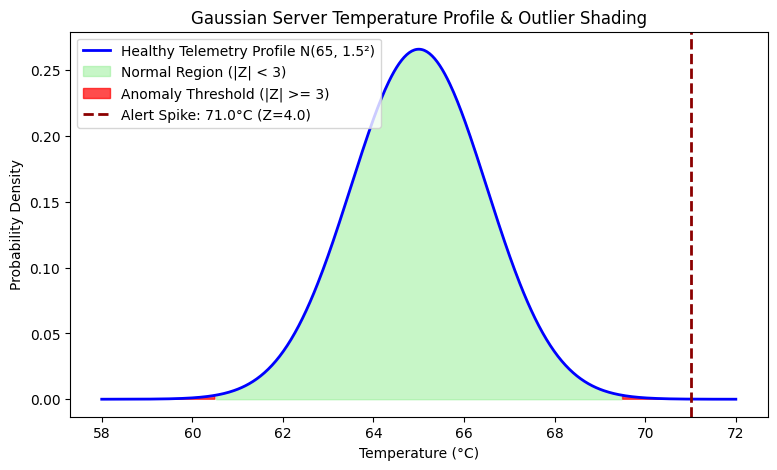

In [3]:
mu, sigma = 65.0, 1.5
x_range = np.linspace(58, 72, 500)
pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_range - mu) / sigma)**2)

plt.figure(figsize=(9, 5))
plt.plot(x_range, pdf, 'b-', linewidth=2, label='Healthy Telemetry Profile N(65, 1.5²)')
plt.fill_between(x_range, pdf, where=(abs(x_range - mu) <= 3*sigma), color='lightgreen', alpha=0.5, label='Normal Region (|Z| < 3)')
plt.fill_between(x_range, pdf, where=(abs(x_range - mu) >= 3*sigma), color='red', alpha=0.7, label='Anomaly Threshold (|Z| >= 3)')

# Flag an anomaly
anomaly_val = 71.0
anomaly_z = (anomaly_val - mu) / sigma
plt.axvline(anomaly_val, color='darkred', linestyle='--', linewidth=2, label=f'Alert Spike: {anomaly_val}°C (Z={anomaly_z:.1f})')

plt.title('Gaussian Server Temperature Profile & Outlier Shading')
plt.xlabel('Temperature (°C)')
plt.ylabel('Probability Density')
plt.legend()
plt.show()


---
## 4. Central Limit Theorem (CLT) Visual Simulation

Regardless of the underlying population distribution, the sample mean $\bar{X}$ converges to a Normal Distribution as sample size $N$ increases.


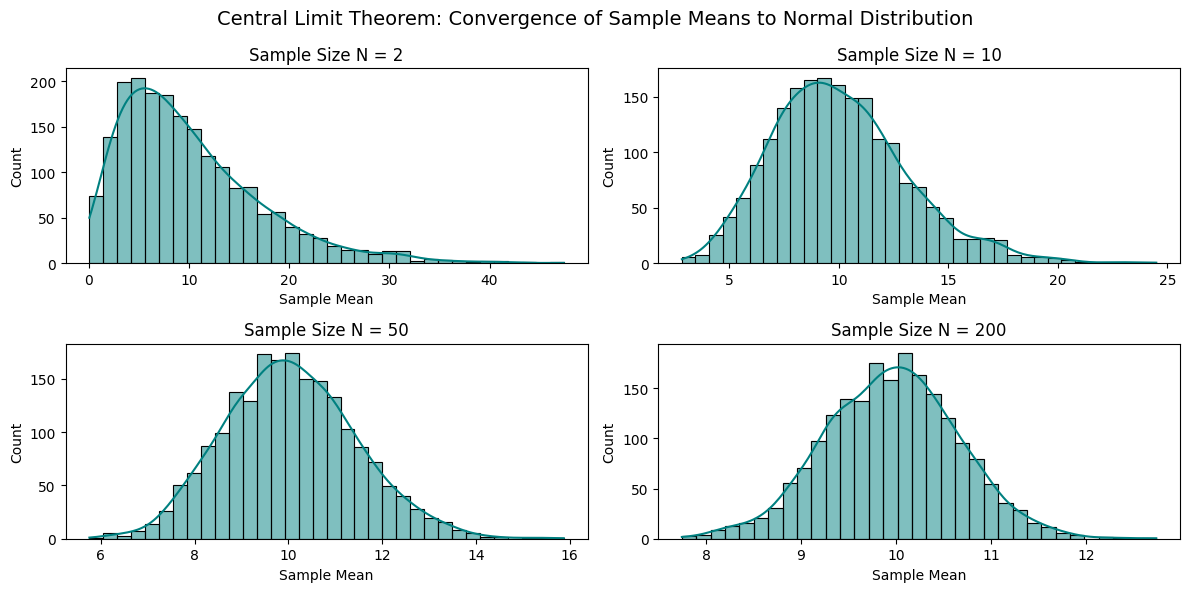

In [4]:
# Heavily skewed exponential distribution
np.random.seed(42)
pop_data = np.random.exponential(scale=10.0, size=100000)

sample_sizes = [2, 10, 50, 200]
plt.figure(figsize=(12, 6))

for idx, n in enumerate(sample_sizes, 1):
    sample_means = [np.mean(np.random.choice(pop_data, size=n)) for _ in range(2000)]
    plt.subplot(2, 2, idx)
    sns.histplot(sample_means, kde=True, color='teal')
    plt.title(f'Sample Size N = {n}')
    plt.xlabel('Sample Mean')

plt.suptitle('Central Limit Theorem: Convergence of Sample Means to Normal Distribution', fontsize=14)
plt.tight_layout()
plt.show()
